# Deep Belief Network (DBN) - TensorFlow / Keras




11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Shape: (60000, 784)
Testing Shape : (10000, 784)

Training RBM Layer 1...
[BernoulliRBM] Iteration 1, pseudo-likelihood = -147.32, time = 12.71s
[BernoulliRBM] Iteration 2, pseudo-likelihood = -126.92, time = 12.35s
[BernoulliRBM] Iteration 3, pseudo-likelihood = -115.32, time = 12.23s
[BernoulliRBM] Iteration 4, pseudo-likelihood = -107.74, time = 9.99s
[BernoulliRBM] Iteration 5, pseudo-likelihood = -102.99, time = 10.63s
[BernoulliRBM] Iteration 6, pseudo-likelihood = -98.83, time = 13.35s
[BernoulliRBM] Iteration 7, pseudo-likelihood = -94.99, time = 12.05s
[BernoulliRBM] Iteration 8, pseudo-likelihood = -92.77, time = 12.10s
[BernoulliRBM] Iteration 9, pseudo-likelihood = -90.36, time = 12.46s
[BernoulliRBM] Iteration 10, pseudo-likelihood = -88.82, time = 9.63s

Training RBM Layer 2...
[BernoulliRBM] Iteration 1, pseudo-likelihood = -107.84, time = 2.14s
[BernoulliRBM] Iteration 2, pseudo-likelihood = -92.66, time = 2.97

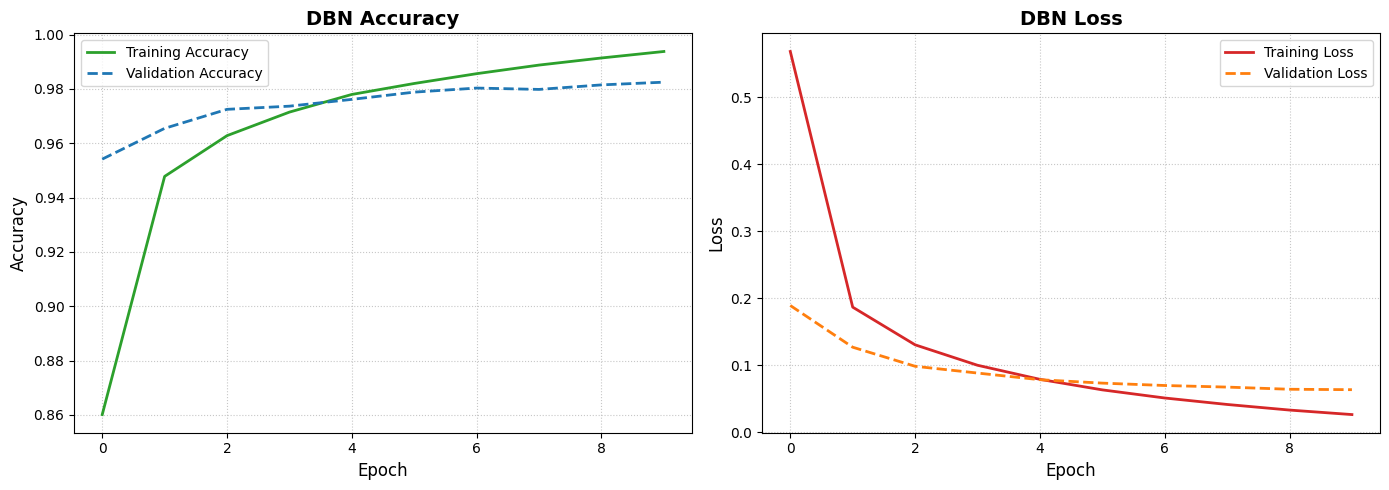

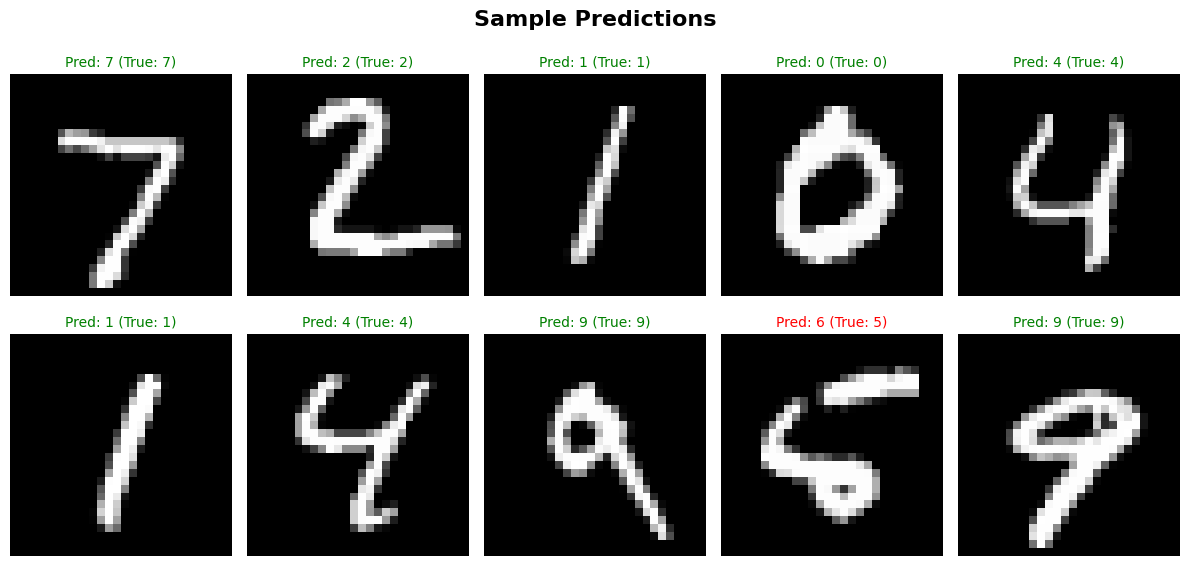

In [1]:
# ============================================================
# Deep Belief Network (DBN) using RBM + TensorFlow/Keras
# Dataset: MNIST
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.neural_network import BernoulliRBM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical

# ============================================================
# 1. Load and Preprocess MNIST Dataset
# ============================================================
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Flatten 28x28 images -> 784 features
x_train = x_train.reshape(-1, 784).astype("float32")
x_test = x_test.reshape(-1, 784).astype("float32")

# Normalize pixel values to [0, 1]
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# One-hot encoding for labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print(f"Training Shape: {x_train.shape}")
print(f"Testing Shape : {x_test.shape}")

# ============================================================
# 2. Train RBMs (Unsupervised Pretraining)
# ============================================================
print("\nTraining RBM Layer 1...")
rbm1 = BernoulliRBM(
    n_components=256,
    learning_rate=0.01,
    batch_size=64,
    n_iter=10,
    random_state=42,
    verbose=True
)
rbm1.fit(x_train)

# Transform data for the next RBM layer
x_train_rbm1 = rbm1.transform(x_train)

print("\nTraining RBM Layer 2...")
rbm2 = BernoulliRBM(
    n_components=128,
    learning_rate=0.01,
    batch_size=64,
    n_iter=10,
    random_state=42,
    verbose=True
)
rbm2.fit(x_train_rbm1)

print("\nRBM pretraining completed!")

# ============================================================
# 3. Build DBN using TensorFlow/Keras
# ============================================================
model = Sequential([
    Input(shape=(784,)),
    Dense(256, activation='sigmoid', name='hidden1'),
    Dense(128, activation='sigmoid', name='hidden2'),
    Dense(10, activation='softmax', name='output')
])

# ============================================================
# 4. Initialize weights from RBMs
# ============================================================
# First hidden layer
W1 = rbm1.components_.T
b1 = rbm1.intercept_hidden_
model.get_layer('hidden1').set_weights([W1, b1])

# Second hidden layer
W2 = rbm2.components_.T
b2 = rbm2.intercept_hidden_
model.get_layer('hidden2').set_weights([W2, b2])

print("\nWeights initialized from RBMs successfully!")

# ============================================================
# 5. Fine-tune with Supervised Learning
# ============================================================
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nStarting Fine-tuning...")
history = model.fit(
    x_train, y_train_cat,
    validation_split=0.1,
    epochs=10,
    batch_size=128,
    verbose=1
)

# ============================================================
# 6. Evaluate Model
# ============================================================
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")

# Predictions
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ============================================================
# 7. Visualization
# ============================================================

# --- Plot 1: Training History (Loss & Accuracy) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', color='#2ca02c', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#1f77b4', linestyle='--', linewidth=2)
ax1.set_title("DBN Accuracy", fontsize=14, fontweight="bold")
ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Accuracy", fontsize=12)
ax1.legend()
ax1.grid(True, linestyle=":", alpha=0.7)

# Loss Plot
ax2.plot(history.history['loss'], label='Training Loss', color='#d62728', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e', linestyle='--', linewidth=2)
ax2.set_title("DBN Loss", fontsize=14, fontweight="bold")
ax2.set_xlabel("Epoch", fontsize=12)
ax2.set_ylabel("Loss", fontsize=12)
ax2.legend()
ax2.grid(True, linestyle=":", alpha=0.7)

plt.tight_layout()
plt.show()

# --- Plot 2: Sample Predictions ---
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.flatten()

for i in range(10):
    img = x_test[i].reshape(28, 28)
    axes[i].imshow(img, cmap='gray')

    # Highlight incorrect predictions in red, correct in green
    color = "green" if y_pred[i] == y_test[i] else "red"
    axes[i].set_title(f"Pred: {y_pred[i]} (True: {y_test[i]})", color=color, fontsize=10)
    axes[i].axis('off')

plt.suptitle("Sample Predictions", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()